# **Laboratorio 2 - Simulación e Inferencia**

# **Introducción**

En la Experiencia 1 se realizó un análisis exploratorio de datos sobre un dataset de expectativa de vida, compuesto por registros de 193 países entre los años 2000 y 2015. El objetivo principal fue comprender el comportamiento general de las variables disponibles, identificar relaciones relevantes y seleccionar aquellas que permitieran formular una pregunta de investigación o hipótesis clara, para así ser trabajada en futuras etapas del proyecto.
Durante el desarrollo se revisaron las variables del dataset, se clasificaron según su tipo y se estudiaron estadísticos descriptivos como media, mediana, moda, rango, varianza y desviación estándar. Además, se usó un mapa de calor para observar correlaciones entre variables, destacando principalmente la relación entre expectativa de vida, índice de desarrollo humano, escolaridad, delgadez en niños y BMI.

También se realizó una limpieza de datos, donde se detectaron valores faltantes y problemas en algunas columnas, especialmente en población. Para evitar perder demasiada información, los datos faltantes fueron reemplazados por la mediana. Luego, se identificaron y eliminaron valores atípicos, buscando trabajar con datos más consistentes.

Finalmente, se seleccionaron como variables principales la expectativa de vida y el índice de desarrollo humano, mientras que como variables secundarias se eligieron la escolaridad promedio y la delgadez entre 5 y 9 años. A partir de este trabajo se formuló la pregunta de investigación: En países con un IDH mayor a la media mundial, ¿cuánto afectan los años de escolaridad a la expectativa de vida?.

A partir de la exploración realizada en la primera experiencia, ya contamos con un dataset limpio, variables seleccionadas y una pregunta de investigación definida. Por esto, en la segunda experiencia el trabajo puede avanzar desde una etapa principalmente descriptiva hacia un análisis más profundo.


In [1]:
import pandas as pd #Para manejar los datos con tablas
import seaborn as sns #Para realizar gráficas estadisticas
import matplotlib.pyplot as plt #Graficos básicos
from scipy.stats import linregress
import numpy as np
import random
ur = 'https://raw.githubusercontent.com/ivanordenes/analisis-datos/refs/heads/main/Life%20Expectancy%20Data.csv' #URL dataset seleccionado

df_original = pd.read_csv(ur)
df=pd.read_csv(ur) #Lee archivo .csv desde la URL y lo guarda

In [ ]:
df_copia = pd.DataFrame(df) #Copia dataframe

In [2]:
print(len(df))   #Limpieza outliers
columnas_analizar = [
    'Life expectancy ',
    'Schooling',
    'Income composition of resources'

]

for columna in columnas_analizar:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    df = df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)]
print(len(df))

2938
2615


Es importante destacar que, tras un análisis más profundo de las variables que vamos a estudiar con los métodos de estimación, decidimos que era necesario eliminar una parte de la limpieza de datos que realizamos en el laboratorio pasado; esta es, la del llenado de datos nulos con la mediana.

Dicha decisión se justificó en su momento en no perder filas o países completos por otras columnas que eran, en un gran porcentaje, nulas. Sin embargo, ahora redujimos considerablemente el número de variables estudiadas, por lo que podemos omitir ese paso, y quedarnos con los valores **reales** del dataset (y no trabajar entonces con números artificiales).

## Parte 1: Estimación Puntual
La variable IDH es perfecta para realizar una estimación puntual (su **media** como **primer parámetro**), ya que es el criterio central de nuestra pregunta de investigación. Como sabemos, el IDH es una media geométrica de tres dimensiones fundamentales para medir el desarrollo de un país: salud (expectativa de vida), educación (años de escolaridad) e ingresos (GDP). Al contar con los datos necesarios en nuestro dataset, el trabajo se resume al desarrollo del código y la normalización de estas variables. Como se describe a continuación, normalizamos utilizando los valores de referencia establecidos por organizaciones dedicadas al desarrollo (PNUD) para llevar las variables a un índice entre 0 y 1.

Posteriormente, calculamos un estimador puntual orientado a responder de forma directa nuestra pregunta de investigación. Para ello, utilizamos la media del IDH calculada anteriormente como un umbral de filtro, aislando así a los países con un nivel de desarrollo sobre el promedio mundial.

Sobre este subgrupo, ajustamos un modelo de regresión lineal (**correlación** entre ambas, **segundo parámetro**) para cuantificar la relación propuesta en nuestra hipótesis. Nuestro estimador puntual de interés es la pendiente de esta regresión ($\beta_1$), la cual representa el efecto aislado de la educación sobre la salud. Al realizar el cálculo, obtuvimos un $\beta_1 \approx 1.4$. Esto se interpreta de la siguiente manera: en los países con un IDH superior al promedio, por cada año adicional de escolaridad que alcanza la población, la expectativa de vida aumenta en aproximadamente 1.4 años.

Finalmente, el análisis de las propiedades básicas de nuestra estimación.

Consistencia: El estimador es altamente consistente, al usar una base de datos robusta (OMS), tenemos muchos registros a lo largo de los años, mientras más crece nuestra base de datos, mas precisa sera nuestra estimacion, permitiendo llegar incluso a un verdadero valor.

Eficiencia: Como usamos una regresion lineal (MCO), nuestro modelo es el mas eficiente ya que tiene la varianza mas pequeña dentro de todos los estimadores lineales e insesgados. Esto garantiza que el margen de error es mínimo.

Sesgo: El estimador es insesgado porque la metodología de MCO asegura que, bajo los supuestos del modelo, el valor esperado de nuestra pendiente es igual al parámetro real de la población. No existe una desviación sistemática en la fórmula que sobreestime o subestime el efecto de la educación en la esperanza de vida.

In [3]:
#Separamos las variables necesarias para la estimacion del IDH.
df_clean = df.dropna(subset=['Life expectancy ', 'Schooling','Income composition of resources','GDP']).copy()

#Hay que normalizar los indices. Para la salud (Life expectancy), desde los 20 a el maximo del dataset, para la educacion (Schooling) se pone como estandar maximo 18 años (establecido por el PNUD), la ultima variable ya es un indice, no es necesario normalizar.

df_clean['I.Salud'] = (df_clean['Life expectancy ']- 20)/(df_clean['Life expectancy '].max()-20)
df_clean['I.Educacion'] = df_clean['Schooling']/18
min_gdp = df_clean['GDP'].min()  #Extremos que sean mas integros con lo que es el dataset
max_gdp = df_clean['GDP'].max()
df_clean['I.Ingreso'] = (np.log(df_clean['GDP'].clip(lower=min_gdp)) - np.log(min_gdp)) / (np.log(max_gdp) - np.log(min_gdp))

#Usamos nuestros indices para calcular el IDH(media geometrica)

df_clean['IDH_Calculado'] = np.cbrt(df_clean['I.Salud'] * df_clean['I.Educacion']*df_clean['I.Ingreso'])

#Estimador puntual (Media global)

estimador_puntual_idh = df_clean['IDH_Calculado'].mean()

print(f"El estimador puntual para el IDH Promedio Mundial es: {estimador_puntual_idh:.4f}")


#Estimador pregunta de hipotesis
#Tenemos que filtrar los paises sobre el promedio de IDH estimado anteriormente

df_alto_idh = df_clean[df_clean['IDH_Calculado']>estimador_puntual_idh].copy()

#Extraemos las variables a comparar

X_escolaridad = df_alto_idh['Schooling']
Y_esperanza = df_alto_idh['Life expectancy ']

#Usamos un regresio lineal

regresion = linregress(X_escolaridad, Y_esperanza)

#Extraemos la pendiente (nuestro estimador del 'Cuanto afecta')

pendiente = regresion.slope


print(f"Países en el grupo de análisis (Sobre el promedio): {len(df_alto_idh)}")

print(f"ESTIMADOR (Pendiente): {pendiente:.4f} años")


El estimador puntual para el IDH Promedio Mundial es: 0.6710
Países en el grupo de análisis (Sobre el promedio): 1252
ESTIMADOR (Pendiente): 1.3774 años


## Parte 2: Métodos de remuestreo: Bootstrap

El metodo bootstrap fue creado por Bradley Efron.
##**Motivación:**
El origen del Bootstrap se remonta a la necesidad de desarrollar un modelo estadístico que rompiera con las limitaciones de las distribuciones teóricas de su época. Tomando como punto de partida el método Jackknife, Bradley Efron diseñó un procedimiento que aprovecha el poder computacional para democratizar el análisis estadístico, permitiendo su aplicación en prácticamente cualquier campo de estudio.

Su importancia radica en haber facilitado el acceso a herramientas de inferencia robustas para diversas disciplinas científicas. Además, destaca por su capacidad para manejar conjuntos de datos del mundo real, que frecuentemente presentan valores atípicos y no se ajustan a distribuciones perfectas, sentando así las bases para el desarrollo de modelos analíticos mucho más avanzados.

##**Importancia actual:**
Su aplicación principal reside en la generación de estimaciones sobre conjuntos de datos que no se ajustan a distribuciones teóricas tradicionales. Al ser un método de estimación no paramétrico, prescinde de supuestos rígidos y depende exclusivamente de la información contenida en la muestra, vinculando su precisión directamente a la calidad con la que dichos datos representan el fenómeno en estudio.

##**Paso a Paso:**
A partir del espacio muestral original, se genera una nueva muestra de igual tamaño mediante un proceso de selección aleatoria con reposición. Este ciclo se repite un número considerable de veces (en nuestro caso, 1,0000 iteraciones), calculando en cada una de ellas el estadístico de interés, como la media o la pendiente de una regresión. Finalmente, los resultados obtenidos se consolidan en un histograma de frecuencias, lo que permite visualizar la distribución del estadístico y determinar sus valores centrales y márgenes de error.

In [4]:
resultados={}  #Diccionario con diferentes estadisticos
resultados['media']=[]
resultados['desviacion_est']=[]
resultados['mediana']=[]
columna = df['Income composition of resources'].dropna()
def boostrap(colmn, result):
    lista_grande=colmn.tolist()  #Pone los valores de la columna en una lista


    for i in range(10000):
      muestra=np.random.choice(colmn, size=len(colmn), replace=True)  #Muestra de largo de la lista, con elementos elegidos de forma aleatoria
      result['media'].append(np.mean(muestra))
      result['desviacion_est'].append(np.std(muestra))
      result['mediana'].append(np.median(muestra))

boostrap(columna, resultados)
prom_boos=np.mean(resultados['media'])
print("Promedio encontrado del IDH " , prom_boos)
print("Promedio encontrado en la columna " , columna.mean())

Promedio encontrado del IDH  0.6610181833269598
Promedio encontrado en la columna  0.6609609942638623


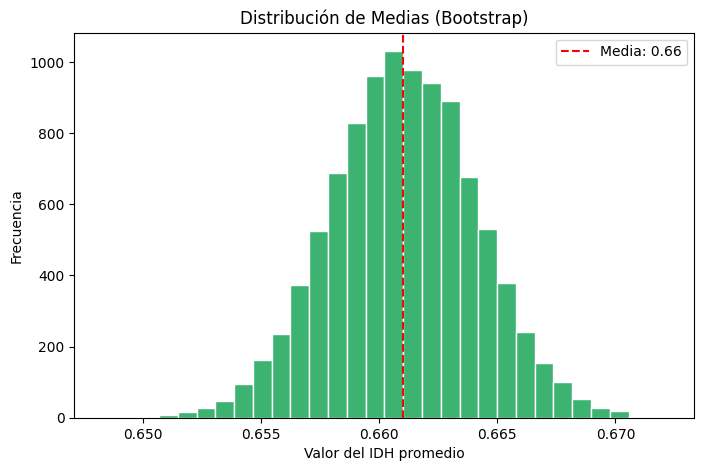

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(resultados['media'], bins=30, color='mediumseagreen', edgecolor='white')

media_final = np.mean(resultados['media'])
plt.axvline(media_final, color='red', linestyle='--', label=f'Media: {media_final:.2f}')

plt.title('Distribución de Medias (Bootstrap)')
plt.xlabel('Valor del IDH promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [6]:
Pendientes=[]
media=df_original['Income composition of resources'].mean()
df_sobreprom=df_original[df_original['Income composition of resources']>media]

def boostrap_part2(df_ej,colmn,otracolm, result):  #Funcion que utiliza el metodo con la pendiente entre dos variables
    df_pend=df_ej[[colmn, otracolm]].dropna().values #Crea una tupla con los valores de las dos columnas

    for i in range(10000):
      indices_rd=np.random.choice(len(df_pend), size=len(df_pend), replace=True)  #Seleccion de diferentes indices aleatorios
      muestra=df_pend[indices_rd]    #Segun los indices va sacando las tuplas
      pendiente= np.polyfit(muestra[:,0], muestra[:,1],1)[0] #Calcula la pendiente utilizando los valores de la tupla mas el intercepto, [0] es para obtener solo la pendiente
      result.append(pendiente)
    print(result)
boostrap_part2(df_sobreprom,'Schooling','Life expectancy ',Pendientes )

print(f"Pendiente promedio: {np.mean(Pendientes):.2f}")

[np.float64(1.5749129882067918), np.float64(1.5606641790293203), np.float64(1.549091028462165), np.float64(1.5127884579986801), np.float64(1.5730790688665486), np.float64(1.6070714064886802), np.float64(1.6381913565914155), np.float64(1.5970454858757372), np.float64(1.5188550752048626), np.float64(1.5761880151706384), np.float64(1.5279092554305764), np.float64(1.4703258864848168), np.float64(1.5872999025479935), np.float64(1.5792498878609478), np.float64(1.6155460509610453), np.float64(1.480819599106005), np.float64(1.6125429211979891), np.float64(1.613360876854208), np.float64(1.5548593422848507), np.float64(1.4954034387010067), np.float64(1.5203041988336163), np.float64(1.544300393359144), np.float64(1.5320188188554822), np.float64(1.5175088171365776), np.float64(1.6140361525102265), np.float64(1.5539193081675908), np.float64(1.5873158937439222), np.float64(1.5582340377764727), np.float64(1.5346957297991235), np.float64(1.5646307496555458), np.float64(1.576784926734967), np.float64(1

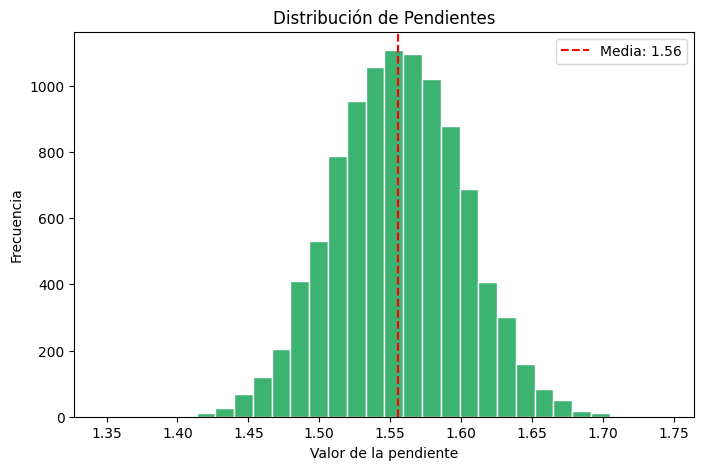

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(Pendientes, bins=30, color='mediumseagreen', edgecolor='white')

media_final = np.mean(Pendientes)
plt.axvline(media_final, color='red', linestyle='--', label=f'Media: {media_final:.2f}')

plt.title('Distribución de Pendientes')
plt.xlabel('Valor de la pendiente')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

##**Comparación con resultados de la estimación puntual**

###**Diferencias**
Si bien se observan proximidades numéricas entre ambas metodologías, existen discrepancias que podrían ser estadísticamente relevantes si se requiere una estimación de alta precisión. Dependiendo de cuál de los dos valores se utilice como referencia, los resultados finales del análisis podrían variar; no obstante, la similitud general entre las cifras sugiere que las estimaciones son consistentes. Cabe destacar que la diferencia más pronunciada se manifiesta en la pendiente de la regresión, lo que indica una mayor sensibilidad de este estadístico ante el proceso de remuestreo.

###**Limitaciones**
Durante la experimentación, se identificaron limitaciones técnicas relevantes. En primer lugar, se observó que el método presenta un techo de convergencia, donde aumentar indefinidamente el número de iteraciones de remuestreo no se traduce en una mejora significativa de la precisión, ya que esta se encuentra acotada por la calidad y el tamaño de la muestra original. Asimismo, debido a su naturaleza aleatoria, los resultados pueden presentar ligeras variaciones entre ejecuciones y una alta sensibilidad ante datos erróneos o valores atípicos, los cuales son replicados y potenciados durante el proceso. Finalmente, cabe destacar el costo computacional involucrado; si bien fue eficiente para este estudio, en escenarios de mayor escala el procesamiento se tornaría considerablemente más lento, lo que exigiría optimizaciones o implementaciones más avanzadas para mantener la viabilidad del análisis.

###**Ventajas**
Una de las principales ventajas del método es su capacidad para exponer la variabilidad de los estadísticos, ofreciendo un panorama mucho más robusto sobre el rango de valores que estos pueden adoptar. Asimismo, destaca por su claridad analítica: al ser representado gráficamente, permite identificar con facilidad tanto la tendencia central como los valores extremos y posibles sesgos. Finalmente, es importante mencionar su flexibilidad metodológica, ya que, al no depender de supuestos matemáticos previos ni de distribuciones teóricas rígidas, se adapta de forma orgánica a los datos reales sin forzar interpretaciones estadísticas.

##**Interpretación**
El análisis de los países con un IDH superior al promedio revela una correlación positiva clara: el incremento en los años de escolaridad se traduce en un aumento considerable de la esperanza de vida. Dado que la relación se mide en años adicionales de longevidad, los resultados constituyen evidencia sólida de una vinculación directa entre ambas variables dentro de este marco impuesto. Este fenómeno sugiere que el acceso a ambientes académicos no solo fomenta una mayor conciencia sobre el autocuidado y la salud, sino que también podria actúar como un catalizador de factores socioeconómicos que, en conjunto, extienden la longevidad de la población en estos países



## Parte 3: Simulación por Monte Carlo
### ¿Qué es?

Un método computacional que busca conocer la probabilidad de distintos escenarios para, por ejemplo, un proceso, que depende de variables aleatorias.
Su funcionamiento consta en generar una gran cantidad (miles, cientos de miles, etc) de valores aleatorios para las variables que determinan el resultado del objeto de estudio, calculándola en cada caso, para analizar al final la distribución y entender el comportamiento de las variables.

Su utilidad (propósito) radica en que entrega una predicción de la realidad estudiada a futuro **cuantificada**, de modo que visibiliza numéricamente sus incertidumbres. Así, diversos campos de estudio lo utilizan para analizar riesgos, y llevar una toma de desiciones estratégicas más objetiva. También se vuelve una valiosa herramienta predictiva para casos donde trabajamos con funciones multivariadas y valores continuos, lo que representa la mayoría de situciones en la vida real: las combinaciones y rangos son prácticamente infinitos, así que nunca podremos comtemplarlos todos. Por ello, Monte Carlo se encarga de obtener un modelo aproximado.

### Situación/fenómeno a simular
Estabilidad del IDH (en países donde este sea mayor o igual a la media mundial) respecto a variaciones de los años de educación promedio: ¿Qué tan sensible es a ellos?

### Modelo de representación

El valor del IDH se obtiene en base a la siguiente fórmula:

$\sqrt[3]{I_{salud} \cdot I_{educación} \cdot I_{ingresos}}$

Donde:

$I_{salud}$ se obtiene con la esperanza de vida,

$I_{ingreso}$ se obtiene a partir del ingreso promedio de la población,

$I_{educación}$ es un promedio de una normalización de los años de educación promedio y los años esperados de educación.

Así, contamos con 3 variables de las cuales el IDH es dependiente, donde nos interesa $I_{educación}$.
Es importante notar que las variables de esta fórmula no son completamente independientes; la escolaridad puede verse afectada por los ingresos, y estos verse afectados a su vez por la escolaridad. Pero, para efectos prácticos, podemos entender que estos cambios son extendidos en el tiempo, de modo que el cambio de los medidores no es inmediato, y nos abstendremos a pensar en periodos más pequeños.

Ahora, como ya hemos escogido una variable de 'enfoque', buscaremos la distribución que mejor la represente. Para eso, generaremos un histograma de la columna 'Schooling' de nuestro dataset (NOTA: como hemos definido en la hipótesis, utilizaremos los datos de aquellos países con un IDH mayor o igual a la media).

De esta forma:
1. Crearemos el histograma de la escolaridad en nuestro grupo de interés del conjunto de datos, y escogeremos la distribución que los represente de mejor manera.
2. Calcularemos el valor de $I_{salud}$ e $I_{ingresos}$, según lo establecido por la PNUD.
3. Se generarán una alta cantidad de valores de escolaridad aleatorios **según la distribución**, de modo que números con los mayores picos de probabilidad serán más propensos a salir (todo según la fórmula de dicha distribución). Para cada una de esas escolaridades promedio, se calculará un IDH.
Tras realizar todas las iteraciones del proceso (calcular todos los IDH), se realizará un historgrama de los resultados calculados, de modo que podremos interpretar la frecuencia con la que ocurrieron.

### Implementación

1. Histograma escolaridad:



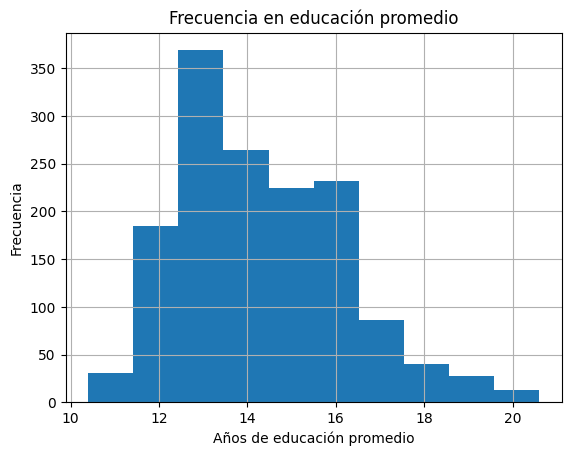

La media de los datos es:  14.305027173913043
La desviación estándar de los datos es:  1.8577968426903995
El valor máximo es:  20.6
El valor mínimo es:  10.4


In [8]:
media = df['Income composition of resources'].mean() #media del IDH
filtro = df[df['Income composition of resources'] >= media] #registros con un IDH myor a esa media

df_filtro = pd.DataFrame(filtro)
df_filtro['Schooling'].hist() #Histograma de este nuevo conjunto de datos
plt.title("Frecuencia en educación promedio")
plt.xlabel("Años de educación promedio")
plt.ylabel("Frecuencia")
plt.show()

media_filtro = df_filtro['Schooling'].mean() #nueva media
std_filtro = df_filtro['Schooling'].std() #nueva desviación estándar
maximo = df_filtro['Schooling'].max()
minimo = df_filtro['Schooling'].min()
print("La media de los datos es: ",media_filtro)
print("La desviación estándar de los datos es: ",std_filtro)
print("El valor máximo es: ",maximo)
print("El valor mínimo es: ",minimo)

Analizando el gráfico, la variable parece seguir una distribución Beta con parámetros $\alpha$ y $\beta$. Estos parámetros se obtienen de la forma:

$\alpha$ = $\mu({{\mu(1-\mu)}\over{\sigma^2}} -1)$

$\beta$ = $(1-\mu)({{\mu(1-\mu)}\over{\sigma^2}} -1)$

Por lo que, en nuestro caso, serán:

In [9]:
media_normalizada = media_filtro/20.6 #dividimos por el valor máximo
std_normalizada = std_filtro/20.6
print("La media normalizada es: ",media_normalizada)
print("La desviación estándar normalizada es: ",std_normalizada)

alfa = media_normalizada*(((media_normalizada*(1-media_normalizada))/(std_normalizada**2))-1) #alfa según fórmula
beta = (1-media_normalizada)*(((media_normalizada*(1-media_normalizada))/(std_normalizada**2))-1) #beta según fórmula

print("\nEl parámetro alfa es: ",alfa)
print("El parámetro beta es: ",beta)

La media normalizada es:  0.6944187948501477
La desviación estándar normalizada es:  0.09018431275196113

El parámetro alfa es:  17.42346928980214
El parámetro beta es:  7.667253223781386


Entonces, si llamamos $S$ a la variable 'Años promedio de escolaridad':
$$S \sim Beta(\alpha = 17.42,\beta = 7.67)$$

2. índice de salud e ingresos
Según el cálculo de la PNUD, el índice de salud se calcula como una normalización respecto al valor máximo y mínimo. En la actualidad, se establece:

$I_{salud}$ = ${esperanza - 20}\over{89 - 20}$, donde 89 es el valor máximo y 20 el mínimo. Para el valor de $esperanza$, utilizaremos la media de la columna de expectativa de vida.

$I_{ingreso}$ = ${ln(ingreso)-ln(100)}\over{ln(40,000)-ln(100)}$, donde 40,000 es el valor máximo y 100 el valor mínimo. Para el valor de $ingreso$, utilizaremos la media de la columna GDP.

Así, estos valores son:

In [10]:
media_esperanza = df_filtro['Life expectancy '].mean()
media_ingreso = df_filtro['GDP'].mean()

i_salud = (media_esperanza-20)/69 #índice de salud
i_ingreso = ((np.log(media_ingreso)-np.log(100))/np.log(400)) #índice de ingreso

print("El índice de salud es: ",i_salud)
print("El índice de ingreso es: ",i_ingreso)

El índice de salud es:  0.8074600267800882
El índice de ingreso es:  0.8090903949584334


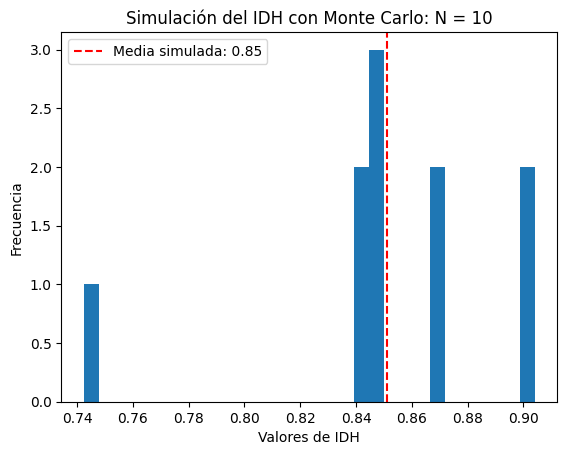

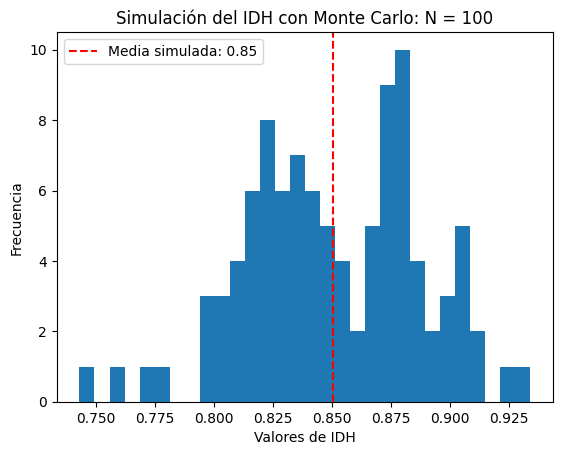

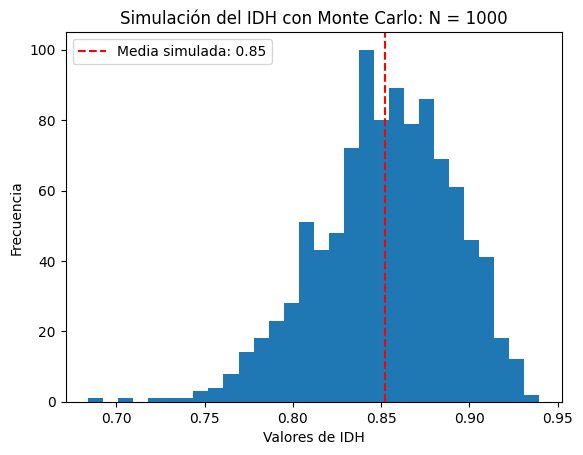

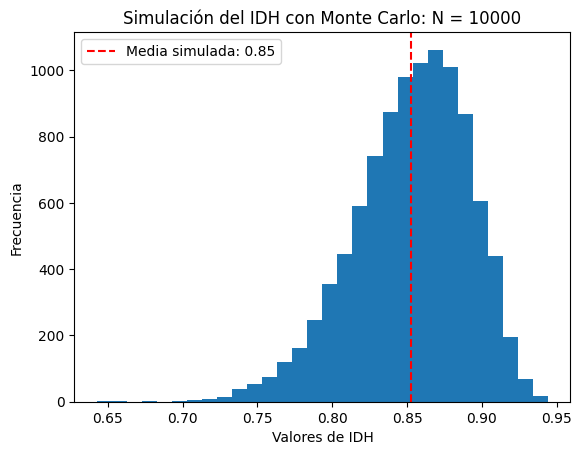

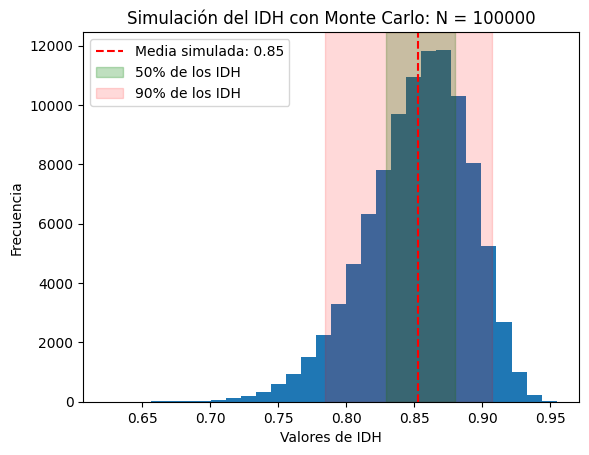

In [11]:
N1 = 10
N2 = 100
N3 = 1000
N4 = 10000
N5 = 100000
valorcito = np.cbrt(i_salud*i_ingreso) #Este es el valor constante de la multiplicación de los índices en raíz cúbica

#PARA 10 VALORES
lista_random = np.zeros(N1) #Lista de tamaño N1 donde todas las casillas tienen el valor 0; esto es para dejarles un valor inicial

for i in range(len(lista_random)):
  lista_random[i] = (np.random.beta(alfa,beta)*20.6)/15 #Generamos N1 valores random en base a la distribución de la variable de escolaridad obtenida antes. Como está normalizada debemos multiplicar por el valor máximo.

lista_IDH = np.zeros(N1) #Una lista como la primera pero para los valores de IDH

for i in range(len(lista_random)):
  lista_IDH[i] = valorcito*np.cbrt(lista_random[i]) #calculamos el IDH para la escolaridad correspondiente

media_simulacion = np.mean(lista_IDH) #media obtenida en la simulación

plt.hist(lista_IDH,bins=30,ec='black')
plt.axvline(media_simulacion, color='red', linestyle='--', label=f'Media simulada: {media_simulacion:.2f}')
plt.title('Simulación del IDH con Monte Carlo: N = 10')
plt.xlabel('Valores de IDH')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#PARA 100 VALORES
lista_random = np.zeros(N2) #Lista de tamaño N2 donde todas las casillas tienen el valor 0; esto es para dejarles un valor inicial

for i in range(len(lista_random)):
  lista_random[i] = (np.random.beta(alfa,beta)*20.6)/15 #Generamos N2 valores random en base a la distribución de la variable de escolaridad obtenida antes. Como está normalizada debemos multiplicar por el valor máximo.

lista_IDH = np.zeros(N2) #Una lista como la primera pero para los valores de IDH

for i in range(len(lista_random)):
  lista_IDH[i] = valorcito*np.cbrt(lista_random[i]) #calculamos el IDH para la escolaridad correspondiente

media_simulacion = np.mean(lista_IDH) #media obtenida en la simulación

plt.hist(lista_IDH,bins=30,ec='black')
plt.axvline(media_simulacion, color='red', linestyle='--', label=f'Media simulada: {media_simulacion:.2f}')
plt.title('Simulación del IDH con Monte Carlo: N = 100')
plt.xlabel('Valores de IDH')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#PARA 1000 VALORES
lista_random = np.zeros(N3) #Lista de tamaño N3 donde todas las casillas tienen el valor 0; esto es para dejarles un valor inicial

for i in range(len(lista_random)):
  lista_random[i] = (np.random.beta(alfa,beta)*20.6)/15 #Generamos N3 valores random en base a la distribución de la variable de escolaridad obtenida antes. Como está normalizada debemos multiplicar por el valor máximo.

lista_IDH = np.zeros(N3) #Una lista como la primera pero para los valores de IDH

for i in range(len(lista_random)):
  lista_IDH[i] = valorcito*np.cbrt(lista_random[i]) #calculamos el IDH para la escolaridad correspondiente

media_simulacion = np.mean(lista_IDH) #media obtenida en la simulación

plt.hist(lista_IDH,bins=30,ec='black')
plt.axvline(media_simulacion, color='red', linestyle='--', label=f'Media simulada: {media_simulacion:.2f}')
plt.title('Simulación del IDH con Monte Carlo: N = 1000')
plt.xlabel('Valores de IDH')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#PARA 10000 VALORES
lista_random = np.zeros(N4) #Lista de tamaño N4 donde todas las casillas tienen el valor 0; esto es para dejarles un valor inicial

for i in range(len(lista_random)):
  lista_random[i] = (np.random.beta(alfa,beta)*20.6)/15 #Generamos N4 valores random en base a la distribución de la variable de escolaridad obtenida antes. Como está normalizada debemos multiplicar por el valor máximo.

lista_IDH = np.zeros(N4) #Una lista como la primera pero para los valores de IDH

for i in range(len(lista_random)):
  lista_IDH[i] = valorcito*np.cbrt(lista_random[i]) #calculamos el IDH para la escolaridad correspondiente

media_simulacion = np.mean(lista_IDH) #media obtenida en la simulación

plt.hist(lista_IDH,bins=30,ec='black')
plt.axvline(media_simulacion, color='red', linestyle='--', label=f'Media simulada: {media_simulacion:.2f}')
plt.title('Simulación del IDH con Monte Carlo: N = 10000')
plt.xlabel('Valores de IDH')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#PARA 100000 VALORES
lista_random = np.zeros(N5) #Lista de tamaño N5 donde todas las casillas tienen el valor 0; esto es para dejarles un valor inicial

for i in range(len(lista_random)):
  lista_random[i] = (np.random.beta(alfa,beta)*20.6)/15 #Generamos N5 valores random en base a la distribución de la variable de escolaridad obtenida antes. Como está normalizada debemos multiplicar por el valor máximo.

lista_IDH = np.zeros(N5) #Una lista como la primera pero para los valores de IDH

for i in range(len(lista_random)):
  lista_IDH[i] = valorcito*np.cbrt(lista_random[i]) #calculamos el IDH para la escolaridad correspondiente

media_simulacion = np.mean(lista_IDH) #media obtenida en la simulación

#percentiles para identificar entre qué valores se acumulan ciertos porcentajes
percentil_5 = np.percentile(lista_IDH, 5)
percentil_25 = np.percentile(lista_IDH, 25)
percentil_75 = np.percentile(lista_IDH, 75)
percentil_95 = np.percentile(lista_IDH, 95)

plt.hist(lista_IDH,bins=30,ec='black')
plt.axvline(media_simulacion, color='red', linestyle='--', label=f'Media simulada: {media_simulacion:.2f}')
plt.axvspan(percentil_25, percentil_75, color='green', alpha=0.25, label='50% de los IDH')
plt.axvspan(percentil_5, percentil_95, color='red', alpha=0.15, label='90% de los IDH')

plt.title('Simulación del IDH con Monte Carlo: N = 100000')
plt.xlabel('Valores de IDH')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

Como podemos ver, mientras mayor sea el número de valores generados, más se juntan los datos y comienzan a parecerce a una curva. Es importante notar igualmente, que las diferencias son más importantes mientras menores sean la cantidad de números: entre 10 y 100, 100 y 1000, y 1000 y 10000, el IDH medio fluctúa, y mayores son las diferencias entre las gráficas (de hecho, para números pequeños de simulación como 10, 100 y 1000, el mismo gráfico puede resultar con otra forma); sin embargo, entre 10000 y 100000, son bastante similares, y el IDH medio es igual.
De cierta forma, es como que nos acercaramos a una cota donde obtenemos la verdadera representación de la variable que estamos estudiando.

### Análisis de resultados

Observando el gráfico con N = 100000, podemos ver que el IDH para el grupo de países estudiado es **robusto** a los cambios en la educación promedio. Ahora, la forma en la que se distribuyen los resultados nos da a entender que es más fácil que el valor *caiga* junto con la educación, a que *crezca* junto con ella, por la especie de 'cola' que tiene hacia la izquierda.